In [1]:
import os
import glob
import random
import cv2
import json
from PIL import Image
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import decord
from torchvision import transforms as T
import torch.nn.functional as F
import matplotlib.pyplot as plt
import torchvision.io as io
import math

In [2]:
def normalize_bbox(bbox, h, w):
    '''
    bbox torch tensor in shape [4] or [...,4], under torch axis
    '''
    bbox_cp = bbox.clone()
    if len(bbox.shape) > 1: # [N,4]
        bbox_cp[..., 0] /= h
        bbox_cp[..., 1] /= w
        bbox_cp[..., 2] /= h
        bbox_cp[..., 3] /= w
        return bbox_cp
    else:
        return torch.tensor([bbox_cp[0]/h, bbox_cp[1]/w, bbox_cp[2]/h, bbox_cp[3]/w])

def recover_bbox(bbox, h, w):
    '''
    bbox torch tensor in shape [4] or [...,4], under torch axis
    '''
    bbox_cp = bbox.clone()
    if len(bbox.shape) > 1: # [N,4]
        bbox_cp[..., 0] *= h
        bbox_cp[..., 1] *= w
        bbox_cp[..., 2] *= h
        bbox_cp[..., 3] *= w
        return bbox_cp
    else:
        return torch.tensor([bbox_cp[0]*h, bbox_cp[1]*w, bbox_cp[2]*h, bbox_cp[3]*w])

def bbox_torchTocv2(bbox):
    '''
    torch, idx 0/2 for height, 1/3 for width (x,y,x,y)
    cv2: idx 0/2 for width, 1/3 for height (y,x,y,x)
    bbox torch tensor in shape [4] or [...,4], under torch axis
    '''
    bbox_cp = bbox.clone()
    if len(bbox.shape) > 1:
        bbox_x1 = bbox_cp[...,0].unsqueeze(-1)
        bbox_y1 = bbox_cp[...,1].unsqueeze(-1)
        bbox_x2 = bbox_cp[...,2].unsqueeze(-1)
        bbox_y2 = bbox_cp[...,3].unsqueeze(-1)
        return torch.cat([bbox_y1, bbox_x1, bbox_y2, bbox_x2], dim=-1)
    else:
        return torch.tensor([bbox_cp[1], bbox_cp[0], bbox_cp[3], bbox_cp[2]])

import torch

def recover_boxes_to_original(bboxes_norm_sq, orig_h, orig_w):
    """
    Invert your padding+normalize pipeline.
    Args:
        bboxes_norm_sq: Tensor [T,4] in [0,1], normalized by the padded square size
                        (this is what __getitem__ returns as 'clip_bbox').
        orig_h, orig_w: integers, original frame height/width (before pad/resize).
    Returns:
        b_abs: Tensor [T,4] absolute pixel coords on the original frame (y1,x1,y2,x2).
        b_norm_orig: Tensor [T,4] normalized by (orig_h, orig_w).
    """
    if bboxes_norm_sq.numel() == 0:
        return bboxes_norm_sq, bboxes_norm_sq

    # Size of the padded square before resize
    h_pad = w_pad = max(orig_h, orig_w)

    # Compute exact padding put on each side (handle odd differences)
    if orig_h < orig_w:
        # padded in height: pad equally (floor on top, ceil on bottom)
        total = orig_w - orig_h
        pad_top  = total // 2
        pad_bot  = total - pad_top
        pad_left = pad_right = 0
    else:
        # padded in width
        total = orig_h - orig_w
        pad_left = total // 2
        pad_right = total - pad_left
        pad_top = pad_bot = 0

    # 1) un-normalize from square
    b = bboxes_norm_sq.clone() * float(h_pad)  # square so h_pad == w_pad

    # 2) remove padding offsets
    # y's: indices 0,2 ; x's: indices 1,3
    b[:, [0, 2]] -= pad_top
    b[:, [1, 3]] -= pad_left

    # 3) clip to original image bounds
    b[:, [0, 2]] = b[:, [0, 2]].clamp(0, orig_h - 1)
    b[:, [1, 3]] = b[:, [1, 3]].clamp(0, orig_w - 1)

    # 4) (optional) normalize by original H/W
    b_norm_orig = b.clone()
    b_norm_orig[:, [0, 2]] /= float(orig_h)
    b_norm_orig[:, [1, 3]] /= float(orig_w)

    return b, b_norm_orig

In [3]:
def sample_frames_balance(num_frames, frame_interval, sample, sampling='rand'):
    '''
    sample clips with balanced negative and positive samples
    params:
        num_frames: total number of frames to sample
        query_frame: query time index
        frame_interval: frame interval, where value 1 is for no interval (consecutive frames)
        sample: data annotations
        sampling: only effective for frame_interval larger than 1
    return: 
        frame_idxs: length [num_frames]
    '''
    required_len = (num_frames - 1) * frame_interval + 1
    anno_valid_idx_range = sample["response_track_valid_range"]
    anno_len = anno_valid_idx_range[1] - anno_valid_idx_range[0] + 1
    
    if anno_len <= required_len:
        if anno_len < required_len:
            num_valid = anno_len // frame_interval
        else:
            num_valid = num_frames
        num_invalid = num_frames - num_valid
        if anno_valid_idx_range[1] < required_len:
            idx_start = random.choice(range(anno_valid_idx_range[0])) if anno_valid_idx_range[0] > 0 else 0
            idx_end = idx_start + required_len
        else:
            num_prior = random.choice(range(num_invalid)) if num_invalid != 0 else 0
            num_post = num_invalid - num_prior
            idx_start = anno_valid_idx_range[0] - frame_interval * num_prior
            idx_end = anno_valid_idx_range[1] + frame_interval * num_post + 1
        intervals = np.linspace(start=idx_start, stop=idx_end, num=num_frames+1).astype(int)
        ranges = []
        for idx, interv in enumerate(intervals[:-1]):
            ranges.append((interv, intervals[idx + 1]))
        if sampling == 'rand':
            frame_idxs_pos = [random.choice(range(x[0], x[1])) for x in ranges]
        elif sampling == 'uniform':
            frame_idxs_pos = [(x[0] + x[1]) // 2 for x in ranges]
    else:
        num_addition = anno_len - required_len
        start = random.choice(range(num_addition))
        frame_idxs_pos = [anno_valid_idx_range[0] + start + it for it in range(num_frames)]
    return frame_idxs_pos

In [4]:
decord.bridge.set_bridge("torch")

# def read_frames_decord_balance(video_path, num_frames, frame_interval, sample, sampling='rand'):
#     video_reader = decord.VideoReader(video_path, num_threads=1)
#     vlen = len(video_reader)
#     # origin_fps = int(video_reader.get_avg_fps())
#     # gt_fps = int(sample['clip_fps'])
#     # down_rate = origin_fps // gt_fps
#     # query_frame = int(sample['query_frame'])
#     frame_idxs = sample_frames_balance(num_frames, frame_interval, sample, sampling)      # downsampled fps idxs, used to get bbox annotation
#     # before_query = torch.tensor(frame_idxs) < query_frame
#     frame_idxs_origin = [min(it, vlen - 1) for it in frame_idxs]        # origin clip fps frame idxs
#     #video_reader.skip_frames(1)
#     frames = video_reader.get_batch(frame_idxs_origin)
#     frames = frames.float() / 255
#     frames = frames.permute(0, 3, 1, 2)
#     return frames, frame_idxs#, before_query

def read_frames_decord_balance(video_path, num_frames, frame_interval, sample, sampling='rand'):
    video_reader = decord.VideoReader(video_path, num_threads=1)
    vlen = len(video_reader)
    origin_fps = int(video_reader.get_avg_fps())
    gt_fps = int(sample.get('clip_fps', origin_fps))
    down_rate = origin_fps // gt_fps
    frame_idxs = sample_frames_balance(num_frames, frame_interval, sample, sampling)      # downsampled fps idxs, used to get bbox annotation
    frame_idxs_origin = [min(it * down_rate, vlen - 1) for it in frame_idxs]        # origin clip fps frame idxs
    #video_reader.skip_frames(1)
    frames = video_reader.get_batch(frame_idxs_origin)
    frames = frames.float() / 255
    frames = frames.permute(0, 3, 1, 2)
    return frames, frame_idxs

In [5]:
class VisualQuery2DDataset(Dataset):
    def __init__(self, clip_params, query_params, data_paths, mode='train', transform=None):
        self.clip_params = clip_params
        self.query_params = query_params
        self.data_paths = data_paths
        self.reduced_data_paths = [path.split('/')[-1] for path in self.data_paths]
        self.mode = mode
        
        if transform is None:
            self.transform = T.Compose([
                T.Resize((self.query_params['query_size'], self.query_params['query_size'])),
                T.ToTensor()
            ])
        else:
            self.transform = transform

        if self.clip_params['padding_value'] == 'zero':
            self.padding_value = 0
        elif self.clip_params['padding_value'] == 'mean':
            self.padding_value = 0.5

        if self.mode == 'train' or self.mode == 'val':
            self.annotations_path = os.path.join(self.data_paths[0].split('/samples')[0], 'annotations/annotations.json')
            self.annotations = self._read_annotations(self.annotations_path)
            self.response_track = {anno['video_id']: [] for anno in self.annotations}
            for anno in self.annotations:
                self.response_track[anno['video_id']] += anno['response_track']
        else:
            self.annotations = None

    def _read_annotations(self, annotation_path):
        with open(annotation_path, 'r') as f:
            anno_json = json.load(f)
        self.annotations = []
        for video in anno_json:
            if video['video_id'] in self.reduced_data_paths:
                for clip_id, clip in enumerate(video['annotations']):
                    response_track_frame_ids = []
                    bboxes = clip['bboxes']
                    for bbox in bboxes:
                        response_track_frame_ids.append(int(bbox['frame']))
                    frame_id_min = min(response_track_frame_ids)
                    frame_id_max = max(response_track_frame_ids)
                    curr_anno = {
                        'video_id': video['video_id'],
                        'clip_id': clip_id, 
                        'response_track': clip['bboxes'],
                        'response_track_valid_range': [frame_id_min, frame_id_max],
                        'object_title': video['video_id'].split('_')[0],
                        'clip_fps': video.get('clip_fps', 30.0)
                    }
                    self.annotations.append(curr_anno)
        return self.annotations

    def _get_clip_bbox(self, sample, clip_idxs, clip_h, clip_w):
        
        clip_with_bbox, clip_bbox = [], []
        # response_track = sample['response_track']
        response_track = self.response_track[sample['video_id']]
        clip_bbox_all = {}
        
        for it in response_track:
            clip_bbox_all[int(it['frame'])] = [it['y1'], it['x1'], it['y2'], it['x2']]

        # print(clip_bbox_all.keys())
        for idx in clip_idxs:
            # print(idx)
            if int(idx) in clip_bbox_all:
                clip_with_bbox.append(True)
                curr_bbox = torch.tensor(clip_bbox_all[int(idx)])
                curr_bbox_normalize = normalize_bbox(curr_bbox, clip_h, clip_w)
                clip_bbox.append(curr_bbox_normalize)
            else:
                clip_with_bbox.append(False)
                clip_bbox.append(torch.tensor([0.0, 0.0, 0.00001, 0.00001]))
        clip_with_bbox = torch.tensor(clip_with_bbox).float()
        clip_bbox = torch.stack(clip_bbox, dim=0)
        return clip_with_bbox, clip_bbox

    def _get_clip_path(self, data_path):
        clip_path = glob.glob(os.path.join(data_path, '*.mp4'))[0]
        return clip_path

    def _get_query_path(self, data_path):
        query_path = glob.glob(os.path.join(data_path, 'object_images', '*.jpg'))
        return query_path
    
    def _process_clip(self, clip, clip_bbox, clip_with_bbox):
        '''
        clip: in [T,C,H,W]
        bbox: in [T,4] with torch coordinate with value range [0,1] normalized
        clip_with_bbox: in [T]
        '''
        target_size = self.clip_params['fine_size']

        t, _, h, w = clip.shape
        clip_bbox = recover_bbox(clip_bbox, h, w)

        try:
            fg_idxs = torch.where(clip_with_bbox)[0].numpy().tolist()
            idx = random.choice(fg_idxs)
            frame = (clip[idx] * 255).permute(1,2,0).numpy().astype(np.uint8)
            frame = Image.fromarray(frame)
            bbox = bbox_torchTocv2(clip_bbox[idx]).tolist()
            query = frame.crop((bbox[0], bbox[1], bbox[2], bbox[3]))
            query_size = self.query_params['query_size']
            query = query.resize((query_size, query_size))
            query = torch.from_numpy(np.asarray(query) / 255.0).permute(2,0,1)
        except:
            query = None

        max_size, min_size = max(h, w), min(h, w)
        pad_height = True if h < w else False
        pad_size = (max_size - min_size) // 2
        if pad_height:
            pad_input = [0, pad_size] * 2                   # for the left, top, right and bottom borders respectively
            clip_bbox[:,0] += (max_size - min_size) / 2.0   # in padded image size
            clip_bbox[:,2] += (max_size - min_size) / 2.0
        else:
            pad_input = [pad_size, 0] * 2
            clip_bbox[:,1] += (max_size - min_size) / 2.0
            clip_bbox[:,3] += (max_size - min_size) / 2.0
        
        transform_pad = T.Pad(pad_input, fill=self.padding_value)
        clip = transform_pad(clip)        # square image
        h_pad, w_pad = clip.shape[-2:]
        clip = F.interpolate(clip, size=(target_size, target_size), mode='bilinear')#.squeeze(0)
        clip_bbox = clip_bbox / float(h_pad)                # in range [0,1]

        # if self.split == 'train':
        #     clip_bbox, clip_with_bbox = self._process_bbox(clip_bbox, clip_with_bbox)
        return clip, clip_bbox, clip_with_bbox, query, h, w

    def __len__(self):
        # Return the total number of samples
        return len(self.annotations)

    def __getitem__(self, idx):
        # Load and return a sample
        sample = self.annotations[idx]
        data_path = os.path.join('/'.join(self.data_paths[0].split('/')[:-1]), sample['video_id'])
        clip_path = self._get_clip_path(data_path)
        query_path = self._get_query_path(data_path)
        query_images = [Image.open(img_path).convert("RGB") for img_path in query_path]
        query_images = [self.transform(img) for img in query_images]
        query_images = torch.stack(query_images, dim=0)
        # query_images = Image.open(query_path[0]).convert("RGB")
        # query_images = self.transform(query_images)
        
        sample_method = self.clip_params['sampling']

        clip, clip_idxs = read_frames_decord_balance(clip_path,
                                                    self.clip_params['num_frames'],
                                                    self.clip_params['frame_interval'],
                                                    sample,
                                                sampling=sample_method)
        # print(clip_idxs)
        # print(sample['response_track'])
        clip_h, clip_w = clip.shape[-2], clip.shape[-1]

        clip_with_bbox, clip_bbox = self._get_clip_bbox(sample, clip_idxs, clip_h, clip_w)
        # print(clip_with_bbox)
        clip, clip_bbox, clip_with_bbox, query, clip_h, clip_w = self._process_clip(clip, clip_bbox, clip_with_bbox)
        
        results = {
            'clip': clip,    # [B, num_frame, C, H, W]
            'clip_with_bbox': clip_with_bbox,
            'clip_bbox': clip_bbox.float(),
            'clip_idxs': torch.tensor(clip_idxs),
            'query_images': query_images,
            'clip_h': clip_h,
            'clip_w': clip_w,
            # 'query': query
        }

        return results

In [6]:
abs_dir = 'D:/OneDrive - Hanoi University of Science and Technology/Domain Basics/Introduction to Deep Learning/Data/train_ego4d/samples'
data_paths = glob.glob(abs_dir+'/*')
data_paths = [p.replace('\\', '/') for p in data_paths]
# np.random.shuffle(data_paths)
train_paths = data_paths[:int(0.8*len(data_paths))]
val_paths = data_paths[int(0.8*len(data_paths)):]

In [7]:
train_paths

['D:/OneDrive - Hanoi University of Science and Technology/Domain Basics/Introduction to Deep Learning/Data/train_ego4d/samples/#unsure_0',
 'D:/OneDrive - Hanoi University of Science and Technology/Domain Basics/Introduction to Deep Learning/Data/train_ego4d/samples/active_spray_cleanser_0',
 'D:/OneDrive - Hanoi University of Science and Technology/Domain Basics/Introduction to Deep Learning/Data/train_ego4d/samples/ac_condenser_0',
 'D:/OneDrive - Hanoi University of Science and Technology/Domain Basics/Introduction to Deep Learning/Data/train_ego4d/samples/bag_0',
 'D:/OneDrive - Hanoi University of Science and Technology/Domain Basics/Introduction to Deep Learning/Data/train_ego4d/samples/bag_1',
 'D:/OneDrive - Hanoi University of Science and Technology/Domain Basics/Introduction to Deep Learning/Data/train_ego4d/samples/bag_2',
 'D:/OneDrive - Hanoi University of Science and Technology/Domain Basics/Introduction to Deep Learning/Data/train_ego4d/samples/bag_3',
 'D:/OneDrive - H

In [8]:
clip_params = {
    'num_frames': 30,
    'frame_interval': 30,
    'sampling': 'rand',
    'fine_size': 256,
    'padding_value': 'zero',
}

query_params = {
    'query_size': 256
}

train_transform = T.Compose([
    T.Resize((query_params['query_size'], query_params['query_size'])),
    T.RandomRotation(30),
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.ToTensor()
])

train_dataset = VisualQuery2DDataset(clip_params, query_params, train_paths, mode='train', transform=train_transform)

In [9]:
# train_dataset[2]

In [24]:
train_dataloader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=0)

In [25]:
len(train_dataloader)

40

In [33]:
sample_data = next(iter(train_dataloader))

In [34]:
# Take indices of bounding boxes
batch_size = sample_data['clip'].size(0)
bbox_indices = [torch.nonzero(sample_data['clip_with_bbox'][b]).view(-1) for b in range(batch_size)]

In [35]:
sample_data['clip_bbox'][sample_data['clip_with_bbox'].bool()].shape

torch.Size([6, 4])

In [36]:
sample_data['clip_bbox'].shape

torch.Size([4, 30, 4])

In [37]:
bbox_indices

[tensor([11]), tensor([9]), tensor([22, 23]), tensor([4, 5])]

256 256
tensor(350) tensor([33.6000,  0.0000, 50.6667, 22.0444])
(18, 23, 3)
256 256
tensor(608) tensor([ 99.4667,  15.4667, 110.0000,  28.4000])
(11, 14, 3)
256 256
tensor(1446) tensor([123.2000,  39.6000, 153.7333,  52.5333])
(31, 14, 3)
256 256
tensor(520) tensor([127.6444, 137.4222, 162.6667, 179.7333])
(36, 43, 3)


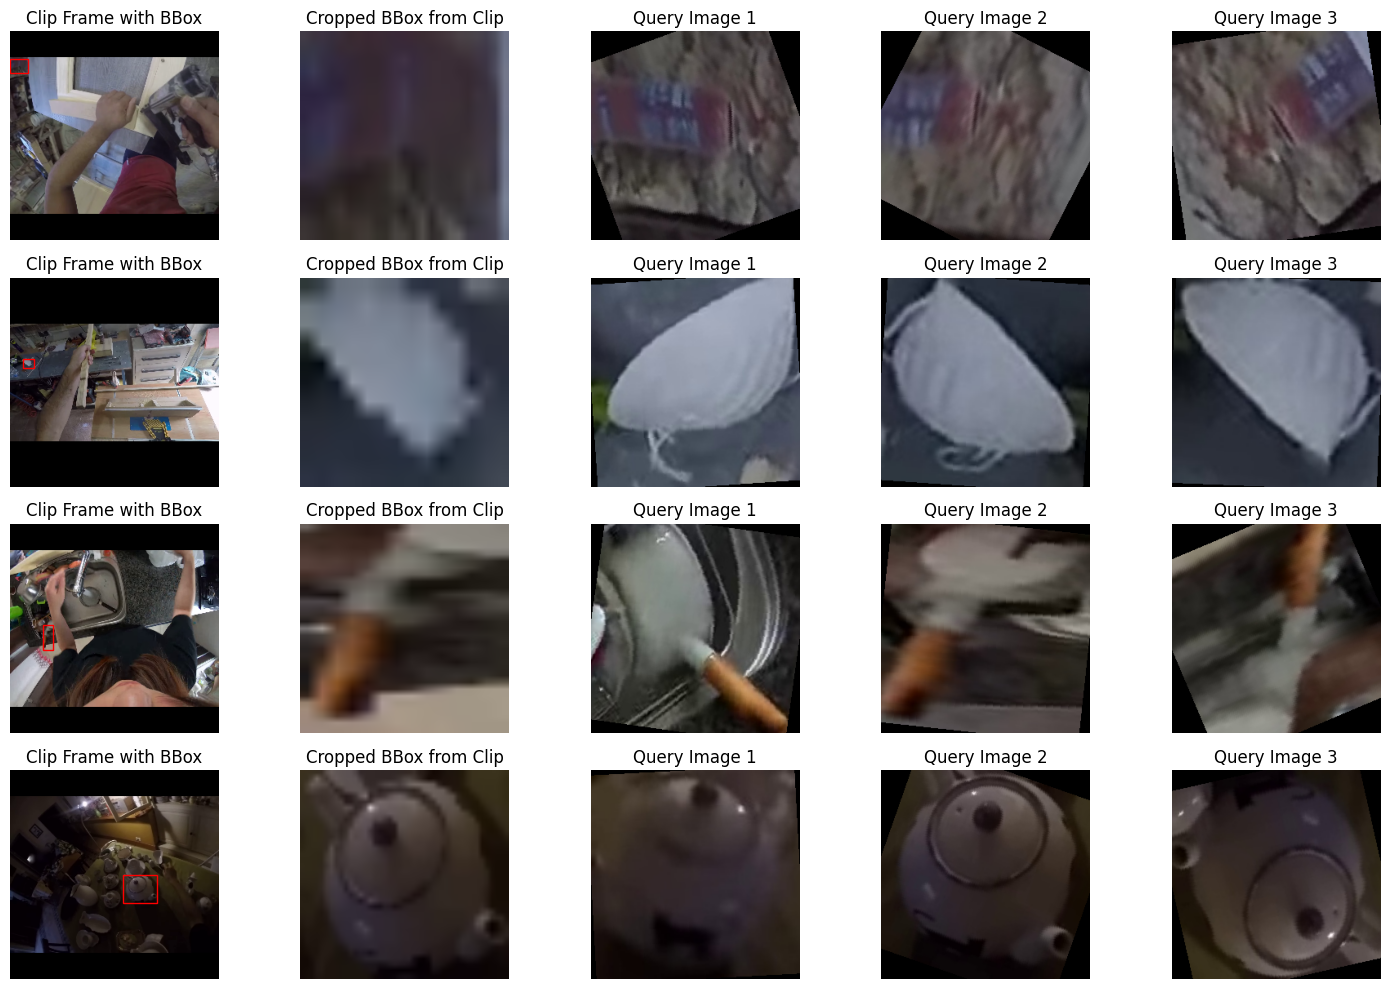

In [38]:
num_sample = 4
fig, axs = plt.subplots(4, 5, figsize=(15,10))
frame = [random.choice(bbox_indices[i]).item() if len(bbox_indices[i])>0 else 0 for i in range(num_sample)]

for i in range(num_sample):
    clip = sample_data['clip'][i, frame[i]].permute(1,2,0).numpy()
    h, w, _ = clip.shape
    print(h, w)
    axs[i, 0].imshow(clip)
    axs[i, 0].axis('off')
    axs[i, 0].set_title('Clip Frame with BBox')
    bbox = sample_data['clip_bbox'][i, frame[i]]
    # bbox = recover_bbox(bbox, h, w)
    bbox = recover_boxes_to_original(bbox.unsqueeze(0), h, w)[0].squeeze(0)
    print(sample_data['clip_idxs'][i, frame[i]], bbox)
    rect = plt.Rectangle((bbox[1], bbox[0]), (bbox[3]-bbox[1]), (bbox[2]-bbox[0]), linewidth=1, edgecolor='r', facecolor='none')
    axs[i, 0].add_patch(rect)
    # Crop the image using the bounding box
    if len(bbox_indices[i]) > 0:
        crop_image = sample_data['clip'][i, frame[i]].permute(1,2,0).numpy()
        y1, x1, y2, x2 = int(bbox[0]), int(bbox[1]), math.ceil(bbox[2]), math.ceil(bbox[3])
        crop_image = crop_image[y1:y2, x1:x2]
        print(crop_image.shape)
        resized_crop = cv2.resize(crop_image, (w, h))
        axs[i, 1].imshow(resized_crop)
        axs[i, 1].axis('off')
        axs[i, 1].set_title('Cropped BBox from Clip')
    axs[i, 2].imshow(sample_data['query_images'][i, 0].permute(1,2,0).numpy())
    axs[i, 2].axis('off')
    axs[i, 2].set_title('Query Image 1')
    axs[i, 3].imshow(sample_data['query_images'][i, 1].permute(1,2,0).numpy())
    axs[i, 3].axis('off')
    axs[i, 3].set_title('Query Image 2')
    axs[i, 4].imshow(sample_data['query_images'][i, 2].permute(1,2,0).numpy())
    axs[i, 4].axis('off')
    axs[i, 4].set_title('Query Image 3')

plt.tight_layout()
plt.show()

In [291]:
num_frames = 30
batch = next(iter(train_dataloader))
fig, ax = plt.subplots(30, 4, figsize=(20, 100))
batch_idx = 0

for i in range (num_frames):
    clip = batch['clip'][batch_idx, i].permute(1, 2, 0).cpu().numpy()
    h, w, _ = clip.shape
    ax[i, 0].imshow(clip)
    ax[i, 0].axis('off')
    if batch['clip_with_bbox'][batch_idx, i] == 1:
        gt_bbox = batch['clip_bbox'][batch_idx, i]
        gt_bbox = recover_bbox(gt_bbox, h, w)
        rect = plt.Rectangle((gt_bbox[1], gt_bbox[0]), (gt_bbox[3]-gt_bbox[1]), (gt_bbox[2]-gt_bbox[0]), linewidth=1, edgecolor='r', facecolor='none')
        ax[i, 0].add_patch(rect)
    ax[i, 0].set_title('GT')
    ax[i, 1].imshow(batch['query_images'][batch_idx, 0].permute(1,2,0).numpy())
    ax[i, 1].axis('off')
    ax[i, 1].set_title('Query Image 1')
    ax[i, 2].imshow(batch['query_images'][batch_idx, 1].permute(1,2,0).numpy())
    ax[i, 2].axis('off')
    ax[i, 2].set_title('Query Image 2')
    ax[i, 3].imshow(batch['query_images'][batch_idx, 2].permute(1,2,0).numpy())
    ax[i, 3].axis('off')
    ax[i, 3].set_title('Query Image 3')

plt.tight_layout()
plt.show()

KeyboardInterrupt: 

In [267]:
def visualize_sample(annotation, data_path):
    object_name = data_path.split('/')[-1]
    clip_path = glob.glob(os.path.join(data_path, '*.mp4'))[0]
    cap = cv2.VideoCapture(clip_path)
    fps = int(cap.get(cv2.CAP_PROP_FPS))
    true_fps = annotation[0].get('clip_fps', fps)
    frame_interval = fps // true_fps
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    bboxes = {}
    
    for video in annotation:
        if video['video_id'] != object_name:
            continue
        else:
            annotations = video['annotations']
            for bbox in annotations:
                bbox_info = bbox['bboxes']
                for frame in bbox_info:
                    bboxes[int(frame['frame'])] = [int(frame['y1']), int(frame['x1']), int(frame['y2']), int(frame['x2'])]
    print(f'Visualizing {object_name}, total frames: {total_frames}, bboxes annotated for {len(bboxes)} frames.')
    print(bboxes)

    new_w, new_h = 1076, 574

    # Get original size
    orig_h, orig_w = height, width

    # Compute scale factors
    scale_x = new_w / orig_w
    scale_y = new_h / orig_h

    # out = cv2.VideoWriter('output.mp4', cv2.VideoWriter_fourcc(*'mp4v'), fps, (width, height))
    for frame in bboxes:
        bboxes[frame] = [
            int(bboxes[frame][0] * scale_y),
            int(bboxes[frame][1] * scale_x),
            int(bboxes[frame][2] * scale_y),
            int(bboxes[frame][3] * scale_x)
        ]

    # out = cv2.VideoWriter('output.mp4', cv2.VideoWriter_fourcc(*'mp4v'), fps, (width, height))

    frame_id = 0
    true_frame_id = 0
    while True:
        ret, frame = cap.read()
        frame = cv2.resize(frame, (new_w, new_h))
        if not ret:
            break
        if frame_id % frame_interval == 0:
            if true_frame_id in bboxes:
                y1, x1, y2, x2 = bboxes[true_frame_id]
                label = object_name.split('_')[0]
                cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
                cv2.putText(
                    frame,
                    label,
                    (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.6,
                    (0, 255, 0),
                    2
                )
            true_frame_id += 1
            print(f'{true_frame_id}')
            cv2.imshow('', frame)
        # out.write(frame)
        if cv2.waitKey(30) & 0xFF == ord('q'):
            break
        frame_id += 1
    cap.release()
    # out.release()
    cv2.destroyAllWindows()

annotation_path = os.path.join(abs_dir.split('/samples')[0], 'annotations/annotations.json')
with open(annotation_path, 'r') as f:
    json_data = json.load(f)
annotation = json_data
visualize_sample(annotation, data_paths[37])

Visualizing chair_1, total frames: 8999, bboxes annotated for 51 frames.
{103: [695, 1309, 946, 1442], 104: [489, 1067, 827, 1340], 105: [410, 977, 757, 1243], 106: [324, 889, 699, 1160], 107: [242, 841, 627, 1104], 108: [178, 810, 579, 1057], 109: [178, 774, 575, 1008], 110: [199, 810, 616, 1038], 111: [151, 848, 591, 1110], 112: [161, 889, 608, 1175], 113: [178, 940, 625, 1240], 114: [161, 920, 613, 1214], 115: [146, 918, 598, 1213], 116: [1054, 0, 1439, 360], 117: [918, 126, 1412, 606], 1206: [0, 1329, 96, 1439], 1207: [0, 1246, 66, 1379], 1208: [0, 1212, 24, 1274], 48: [680, 978, 828, 1070], 49: [652, 1100, 803, 1194], 50: [552, 1184, 746, 1272], 51: [532, 1165, 728, 1252], 52: [486, 1211, 694, 1297], 53: [552, 994, 705, 1079], 54: [623, 869, 719, 957], 55: [662, 834, 773, 919], 56: [659, 804, 814, 894], 57: [656, 777, 892, 876], 58: [708, 737, 937, 842], 59: [733, 730, 965, 835], 60: [679, 675, 918, 780], 61: [654, 548, 891, 653], 62: [662, 399, 918, 518], 63: [629, 291, 895, 400]

In [123]:
data_paths

['D:/OneDrive - Hanoi University of Science and Technology/Domain Basics/Introduction to Deep Learning/Data/train/samples/Backpack_1',
 'D:/OneDrive - Hanoi University of Science and Technology/Domain Basics/Introduction to Deep Learning/Data/train/samples/WaterBottle_1',
 'D:/OneDrive - Hanoi University of Science and Technology/Domain Basics/Introduction to Deep Learning/Data/train/samples/Lifering_0',
 'D:/OneDrive - Hanoi University of Science and Technology/Domain Basics/Introduction to Deep Learning/Data/train/samples/MobilePhone_0',
 'D:/OneDrive - Hanoi University of Science and Technology/Domain Basics/Introduction to Deep Learning/Data/train/samples/Person1_0',
 'D:/OneDrive - Hanoi University of Science and Technology/Domain Basics/Introduction to Deep Learning/Data/train/samples/Person1_1',
 'D:/OneDrive - Hanoi University of Science and Technology/Domain Basics/Introduction to Deep Learning/Data/train/samples/Backpack_0',
 'D:/OneDrive - Hanoi University of Science and Tec

In [ ]:
from decord import VideoReader, cpu

num_frames = 30
video_path = 'D:/OneDrive - Hanoi University of Science and Technology/Domain Basics/Introduction to Deep Learning/Data/public_test/samples/BlackBox_0/drone_video.mp4'
image_path = ''
vr = VideoReader(video_path, ctx=cpu(0))
total_frames = len(vr)
all_clips = []
for i in range(0, total_frames, num_frames):
    clip = vr.get_batch(range(i, min(i+num_frames, total_frames)))
    all_clips.append(clip)
    if len(all_clips) == 4:
        all_clips = torch.cat(all_clips, dim=0)
        results = model()
all_clips = torch.cat(all_clips, dim=0)
all_clips.shape

OSError: [WinError -529697949] Windows Error 0xe06d7363